<a href="https://colab.research.google.com/github/drivera27/Employee-Churn-Project/blob/main/Employee_Churn_Pilot_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Churn Project (Pilot Analysis)

## Setup

### Importing libraries

In [1]:
# import libraries
from google.cloud import bigquery
from google.colab import auth

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Retrieving data via BigQuery

In [2]:
auth.authenticate_user()

# initialize client for bigquery
project_id = 'employee-churn-488016'
client = bigquery.Client(project=project_id, location='US')

# connect to bigquery database
dataset_ref = client.dataset('employee_data', project=project_id)
dataset = client.get_dataset(dataset_ref)

In [3]:
# retrieve original table
table = client.get_table(dataset.table('tbl_hr_data'))

# convert table to dataframes and verify
df = client.list_rows(table=table).to_dataframe()
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.38,0.53,2,157,3,0,1,0,sales,low,EMP00001
1,0.80,0.86,5,262,6,0,1,0,sales,medium,EMP00002
2,0.11,0.88,7,272,4,0,1,0,sales,medium,EMP00003
3,0.72,0.87,5,223,5,0,1,0,sales,low,EMP00004
4,0.37,0.52,2,159,3,0,1,0,sales,low,EMP00005


In [4]:
# retrieve pilot table
new_table = client.get_table(dataset.table('tbl_new_employees'))

# convert new table to dataframe and verify
df2 = client.list_rows(table=new_table).to_dataframe()
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082


## EDA

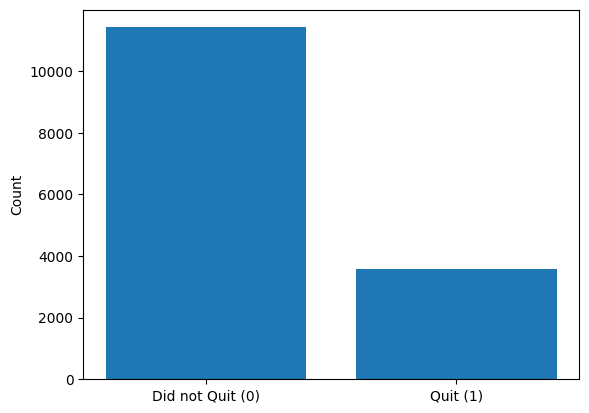

In [5]:
# display bar chart with quitting and non-quitting employees
quit_count = df['Quit_the_Company'].value_counts()

plt.bar(quit_count.index, quit_count.values,
        tick_label=['Did not Quit (0)', 'Quit (1)'])
plt.ylabel('Count')
plt.show();

As shown, there are far more employees who did not quit than those who did, which means our two classes are heavily imbalanced. Because of the imbalance, accuracy may not be the best metric to test our model's performance. Instead, it is best to use F1 score as our primary metric when evaluating our model. F1 score takes an average of two other metrics (precision and recall), and is better at handling imbalanced classes in datasets.

## Modeling

### Preparing the data

First, I want to check if either dataframe has any rows with null values, and how many. Any null values can interrupt the modeling process.

If there is only a small amount of nulls, they can safely be dropped. However, if there are too many nulls, the data will have to be reviewed and/or modified.

In [6]:
df[df.isna().any(axis=1)]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
14999,0.40,0.57,<NA>,151,<NA>,0,1,0,support,low,EMP15000
15000,0.37,0.48,<NA>,160,<NA>,<NA>,1,0,support,low,EMP15001
15001,0.37,0.53,<NA>,143,<NA>,<NA>,1,0,support,low,EMP15002
15002,0.11,0.96,<NA>,280,<NA>,<NA>,1,0,support,low,EMP15003
15003,0.37,0.52,<NA>,158,<NA>,<NA>,1,0,support,low,EMP15004


In [7]:
df2[df2.isna().any(axis=1)]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id


The original employee dataframe, `df`, has 5 rows with nulls for multiple columns. Since these only make up a very small amount of our total data (5 out of 15004), I will drop these rows before building the model.

In [8]:
# drop rows with null values from df
df = df.dropna()

# ensure that only the 5 null rows were dropped
print('Number of rows:', df.shape[0])
df[df.isna().any(axis=1)]

Number of rows: 14999


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id


Now that both dataframes have been cleaned and prepared, we can start to build the model.

### Building the Model

In [9]:
def build_model(data):
  '''This function first prepares the data, then uses sk-learn's
  Random Forest classifier to build a model to predict employee churn.'''

  # drop irrelevant columns
  data = data.drop(columns=['employee_id'])

  # separate independent and dependent (target) features
  X = data.drop(columns=['Quit_the_Company'], axis=1)
  y = data['Quit_the_Company']

  # identify categorical and numerical variables
  categorical = ['Departments', 'salary']
  numerical = X.columns[:2].tolist()

  # create a preprocessor
  # transform categorical variables into numerical using one-hot encoding
  preprocessor = ColumnTransformer(
      transformers=[
          ('cat',
           OneHotEncoder(handle_unknown='ignore'), categorical)
      ], remainder='passthrough')

  # build RF model using Pipeline
  model = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', RandomForestClassifier(random_state=27))]) # random seed to reproduce results

  # split data for training and testing (80:20)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27, stratify=y)

  # train RF model
  model.fit(X_train, y_train)

  # predict using test set
  predictions = model.predict(X_test)

  # return classification report to evaluate predictions
  # using sklearn
  print(classification_report(y_test, predictions))

  # return model (now trained)
  return model

### Predicting Employee Churn

In [10]:
# call our function to build a model using the employees data
# then observe results
model = build_model(data=df)

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      2286
         1.0       0.99      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [11]:
# use our model to predict using the NEW employee data
df2_predictions = model.predict(df2)
df2_predictions

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [12]:
# add predictions to the new employee dataframe
df2['Quit_prediction'] = df2_predictions
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id,Quit_prediction
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043,0.0
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086,0.0
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035,0.0
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069,0.0
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082,0.0


In [29]:
# filter df2 for employees predicted to quit
quit_pred_df = df2[df2['Quit_prediction'] == 1].sort_values(by='employee_id')
quit_pred_df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id,Quit_prediction
70,0.468434,0.169659,5,303,4,0,0,0,IT,low,NE15015,1.0
24,0.088118,0.626649,3,264,2,1,0,0,management,medium,NE15036,1.0
40,0.114685,0.820722,3,144,3,1,0,0,technical,medium,NE15052,1.0
36,0.049413,0.830307,3,242,4,0,0,0,support,high,NE15054,1.0
25,0.111997,0.855752,3,255,2,1,0,0,management,medium,NE15065,1.0
41,0.028848,0.565016,3,279,3,1,0,0,technical,low,NE15089,1.0
61,0.433835,0.035243,4,309,4,0,0,0,sales,medium,NE15100,1.0
67,0.050319,0.094472,4,254,5,0,0,0,support,low,NE15103,1.0


In [28]:
# return the IDs of employees predicted to quit
id_list = quit_pred_df['employee_id'].values

print('Employees at high risk of quitting:')
for i in id_list:
  print(i)

Employees at high risk of quitting:
NE15015
NE15036
NE15052
NE15054
NE15065
NE15089
NE15100
NE15103
